## 4) Diagrama de flujo

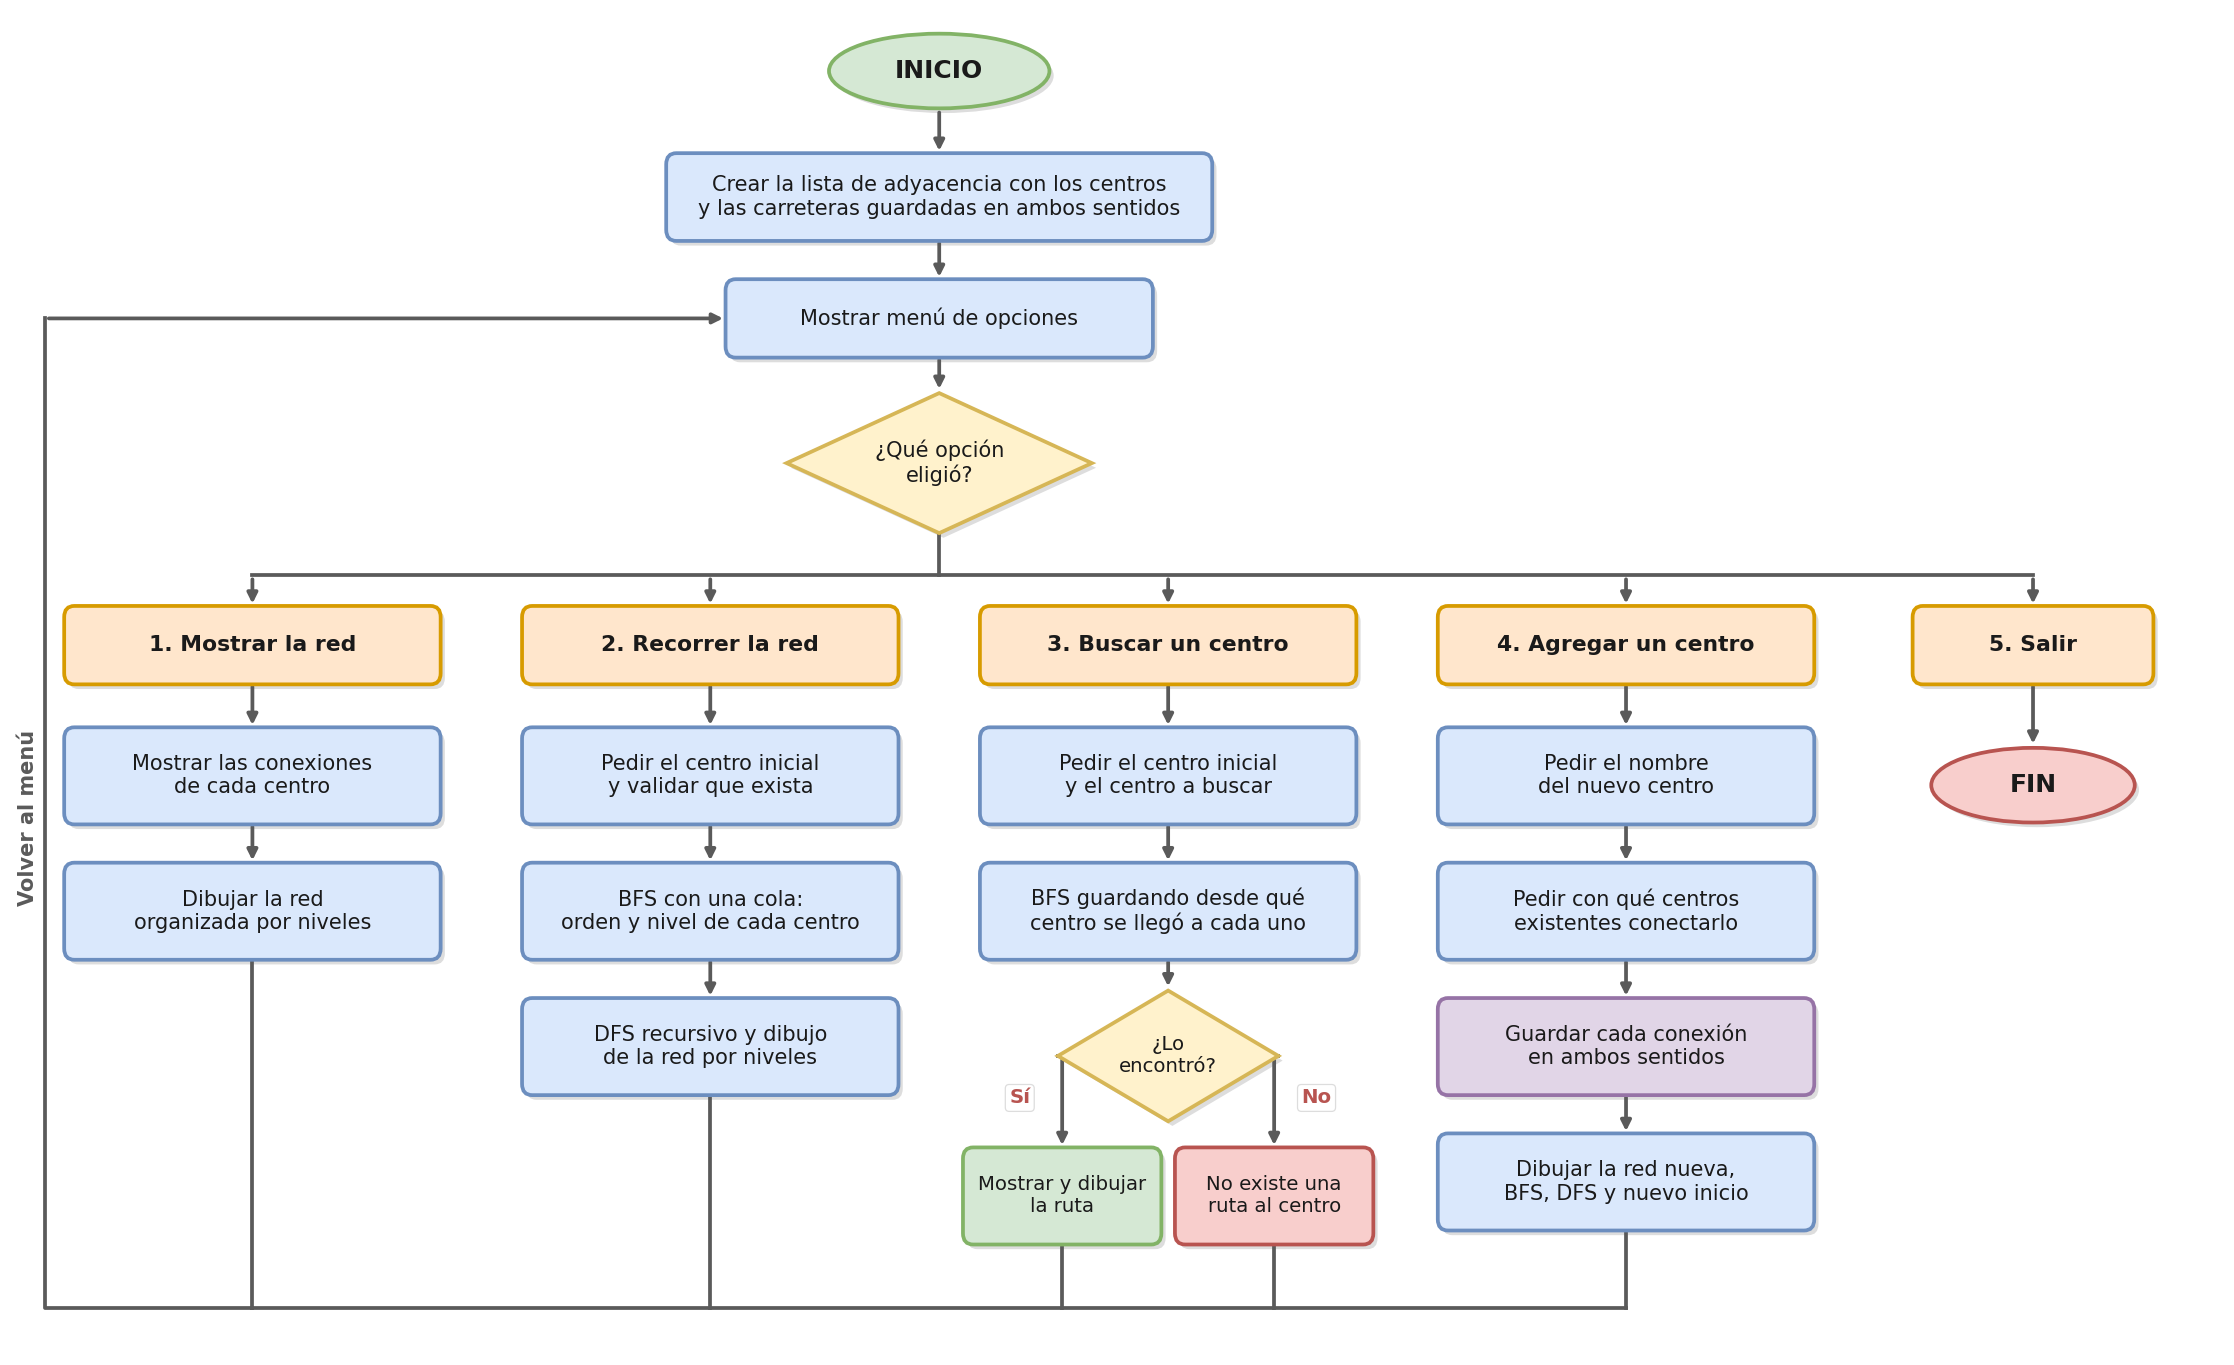

Al iniciar se crea la lista de adyacencia y se muestra el menú. Según la opción, el programa muestra la red, la recorre con BFS y DFS desde el centro que elija el usuario, busca un centro o agrega uno nuevo. Después de cada opción vuelve al menú, hasta que el usuario elige salir.

## 8) Código funcional

La red se guarda en un diccionario donde cada centro tiene la lista de sus vecinos. BFS usa una cola (`deque`) y DFS se hace con recursividad; en los dos se lleva un conjunto de visitados para no pasar dos veces por el mismo centro. Para buscar un centro se usa BFS guardando desde qué centro se llegó a cada uno, y así se reconstruye la ruta. `dibujar_red` muestra la red por niveles, con un color para cada centro, y si recibe una ruta la marca en rojo.

In [ ]:
import sys
from collections import deque
import matplotlib.pyplot as plt

sys.setrecursionlimit(100000)


nombres = {
    "A": "Centro principal",
    "B": "Centro Norte",
    "C": "Centro Sur",
    "D": "Centro Occidente",
    "E": "Centro Oriente",
    "F": "Centro Industrial",
    "G": "Centro Aeropuerto",
}

carreteras = [("A", "B"), ("A", "C"), ("B", "D"), ("B", "E"), ("C", "F"), ("E", "G"), ("F", "G")]


def conectar(grafo, a, b):
    if b not in grafo[a]:
        grafo[a].append(b)
    if a not in grafo[b]:
        grafo[b].append(a)


def crear_grafo(centros, carreteras):
    grafo = {}
    for centro in centros:
        grafo[centro] = []
    for a, b in carreteras:
        conectar(grafo, a, b)
    return grafo


def mostrar_grafo(grafo):
    for centro, vecinos in grafo.items():
        nombre = nombres.get(centro, "Centro nuevo")
        conexiones = ", ".join(vecinos) if vecinos else "sin conexiones"
        print(f"{centro} ({nombre}): {conexiones}")


def bfs(grafo, inicio):
    visitados = {inicio}
    cola = deque([inicio])
    orden = []
    nivel = {inicio: 0}
    while cola:
        actual = cola.popleft()
        orden.append(actual)
        for vecino in grafo[actual]:
            if vecino not in visitados:
                visitados.add(vecino)
                nivel[vecino] = nivel[actual] + 1
                cola.append(vecino)
    return orden, nivel


def dfs(grafo, inicio, visitados=None, orden=None):
    if visitados is None:
        visitados = set()
        orden = []
    visitados.add(inicio)
    orden.append(inicio)
    for vecino in grafo[inicio]:
        if vecino not in visitados:
            dfs(grafo, vecino, visitados, orden)
    return orden


def niveles_por_grupo(nivel):
    grupos = {}
    for centro, n in nivel.items():
        grupos.setdefault(n, []).append(centro)
    return grupos


def buscar_ruta(grafo, inicio, destino):
    visitados = {inicio}
    anterior = {inicio: None}
    cola = deque([inicio])
    while cola:
        actual = cola.popleft()
        if actual == destino:
            ruta = []
            while actual is not None:
                ruta.append(actual)
                actual = anterior[actual]
            return ruta[::-1]
        for vecino in grafo[actual]:
            if vecino not in visitados:
                visitados.add(vecino)
                anterior[vecino] = actual
                cola.append(vecino)
    return None


def agregar_centro(grafo, centro, vecinos):
    if centro not in grafo:
        grafo[centro] = []
    for vecino in vecinos:
        if vecino in grafo and vecino != centro:
            conectar(grafo, centro, vecino)


def existe(grafo, centro):
    if centro in grafo:
        return True
    print(f"Error: el centro {centro} no existe en la red.")
    return False


def recorrer(grafo, inicio):
    if not existe(grafo, inicio):
        return
    orden, nivel = bfs(grafo, inicio)
    print(f"Recorrido BFS desde {inicio}: {' -> '.join(orden)}")
    for n, centros in niveles_por_grupo(nivel).items():
        print(f"  Nivel {n}: {', '.join(centros)}")
    print(f"Recorrido DFS desde {inicio}: {' -> '.join(dfs(grafo, inicio))}")
    sin_ruta = [c for c in grafo if c not in nivel]
    if sin_ruta:
        print(f"Centros sin ruta desde {inicio}: {', '.join(sin_ruta)}")


def mostrar_busqueda(grafo, inicio, destino):
    if not existe(grafo, inicio) or not existe(grafo, destino):
        return
    ruta = buscar_ruta(grafo, inicio, destino)
    if ruta is None:
        print("No existe una ruta hasta el centro solicitado.")
    else:
        print(f"Centro encontrado. Ruta: {' -> '.join(ruta)}")
        print(f"Cantidad de conexiones: {len(ruta) - 1}")
        dibujar_red(grafo, inicio, f"Ruta de {inicio} a {destino}", ruta)


def dibujar_red(grafo, inicio, titulo, ruta=None):
    _, nivel = bfs(grafo, inicio)
    filas = niveles_por_grupo(nivel)
    sin_ruta = [c for c in grafo if c not in nivel]
    if sin_ruta:
        filas[max(filas) + 1] = sin_ruta

    posiciones = {}
    for n, centros in filas.items():
        for i, centro in enumerate(centros):
            posiciones[centro] = (i - (len(centros) - 1) / 2, -n)

    color = {}
    for i, centro in enumerate(grafo):
        color[centro] = plt.cm.tab10(i % 10)

    tramos = set()
    if ruta:
        for a, b in zip(ruta, ruta[1:]):
            tramos.add((a, b))
            tramos.add((b, a))

    dibujadas = set()
    plt.figure(figsize=(9, 6))
    for centro, vecinos in grafo.items():
        for vecino in vecinos:
            if (vecino, centro) in dibujadas:
                continue
            dibujadas.add((centro, vecino))
            (x1, y1), (x2, y2) = posiciones[centro], posiciones[vecino]
            origen = centro if nivel.get(centro, 99) <= nivel.get(vecino, 99) else vecino
            if ruta is None:
                plt.plot([x1, x2], [y1, y2], color=color[origen], linewidth=2, zorder=1)
            elif (centro, vecino) in tramos:
                plt.plot([x1, x2], [y1, y2], color="#d62728", linewidth=5, zorder=1)
            else:
                plt.plot([x1, x2], [y1, y2], color="#d0d0d0", linewidth=1.5, zorder=1)

    for centro, (x, y) in posiciones.items():
        relleno = color[centro]
        if ruta is not None and centro not in ruta:
            relleno = "#c7c7c7"
        plt.scatter(x, y, s=1400, color=relleno, zorder=2)
        plt.text(x, y, centro, ha="center", va="center", color="white", fontsize=15, fontweight="bold", zorder=3)

    plt.title(titulo)
    plt.axis("off")
    plt.margins(0.15)
    plt.show()


def pedir_centro(grafo, mensaje):
    centro = input(mensaje).strip().upper()
    if existe(grafo, centro):
        return centro
    return None


def menu(grafo):
    while True:
        print("\n1. Mostrar la red")
        print("2. Recorrer la red con BFS y DFS")
        print("3. Buscar un centro")
        print("4. Agregar un centro")
        print("5. Salir")
        opcion = input("Elija una opción: ").strip()

        if opcion == "1":
            mostrar_grafo(grafo)
            dibujar_red(grafo, "A", "Red de distribución por niveles desde A")

        elif opcion == "2":
            inicio = pedir_centro(grafo, "Ingrese el centro inicial: ")
            if inicio:
                recorrer(grafo, inicio)
                dibujar_red(grafo, inicio, f"Red por niveles desde {inicio}")

        elif opcion == "3":
            inicio = pedir_centro(grafo, "Centro inicial: ")
            if inicio:
                destino = pedir_centro(grafo, "Centro que desea buscar: ")
                if destino:
                    mostrar_busqueda(grafo, inicio, destino)

        elif opcion == "4":
            nuevo = input("Ingrese el nuevo centro: ").strip().upper()
            if not nuevo:
                print("El nombre del centro no puede estar vacío.")
                continue
            vecinos = []
            while True:
                vecino = input(f"Conectar {nuevo} con (Enter para terminar): ").strip().upper()
                if not vecino:
                    break
                if vecino == nuevo:
                    print("Un centro no puede conectarse consigo mismo.")
                elif existe(grafo, vecino):
                    vecinos.append(vecino)
            agregar_centro(grafo, nuevo, vecinos)

            print("\nLista de adyacencia actualizada:")
            mostrar_grafo(grafo)
            dibujar_red(grafo, "A", f"Red con el nuevo centro {nuevo}")
            recorrer(grafo, "A")
            inicio = pedir_centro(grafo, "\nIngrese el centro inicial para recorrer la red nueva: ")
            if inicio:
                recorrer(grafo, inicio)
                dibujar_red(grafo, inicio, f"Red por niveles desde {inicio}")

        elif opcion == "5":
            print("Programa finalizado.")
            break

        else:
            print("Opción no válida.")


### Prueba con los datos del enunciado

PUNTO 1. Lista de adyacencia
A (Centro principal): B, C
B (Centro Norte): A, D, E
C (Centro Sur): A, F
D (Centro Occidente): B
E (Centro Oriente): B, G
F (Centro Industrial): C, G
G (Centro Aeropuerto): E, F


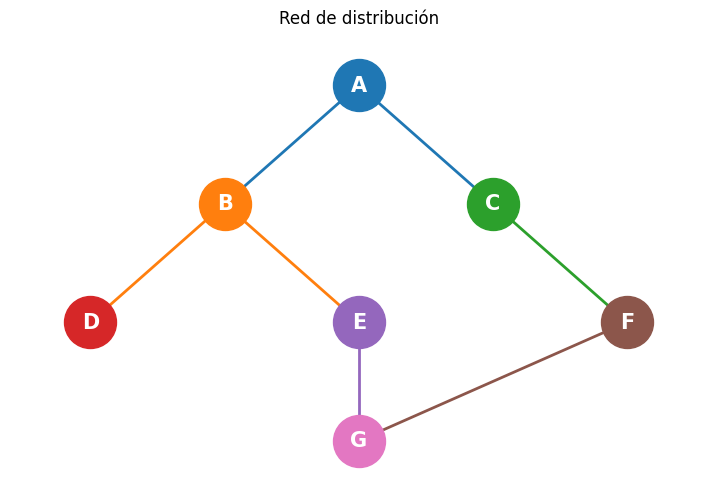

PUNTOS 2 Y 3. Recorridos desde el centro principal
Recorrido BFS desde A: A -> B -> C -> D -> E -> F -> G
  Nivel 0: A
  Nivel 1: B, C
  Nivel 2: D, E, F
  Nivel 3: G
Recorrido DFS desde A: A -> B -> D -> E -> G -> F -> C

PUNTO 4. Recorridos desde el centro que elige el usuario
Recorrido BFS desde B: B -> A -> D -> E -> C -> G -> F
  Nivel 0: B
  Nivel 1: A, D, E
  Nivel 2: C, G
  Nivel 3: F
Recorrido DFS desde B: B -> A -> C -> F -> G -> E -> D


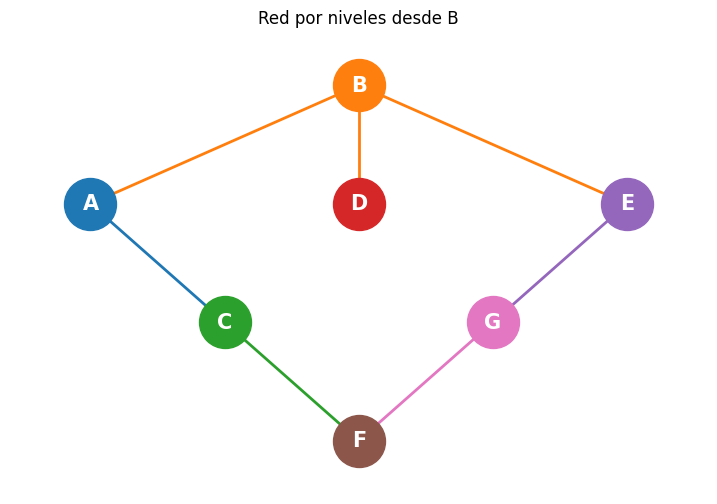

Si el usuario escribe un centro que no existe, por ejemplo Z:
Error: el centro Z no existe en la red.

PUNTO 5. Buscar un centro con BFS
Centro encontrado. Ruta: A -> C -> F
Cantidad de conexiones: 2


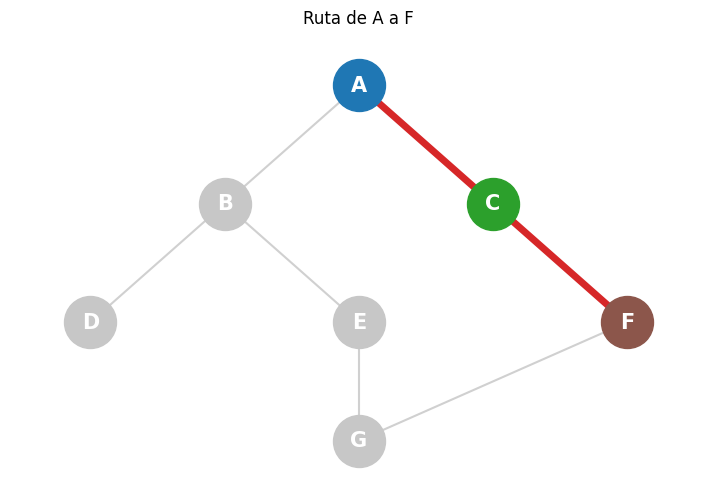

PUNTO 6. Agregar el centro H conectado con D y G
A (Centro principal): B, C
B (Centro Norte): A, D, E
C (Centro Sur): A, F
D (Centro Occidente): B, H
E (Centro Oriente): B, G
F (Centro Industrial): C, G
G (Centro Aeropuerto): E, F, H
H (Centro nuevo): D, G


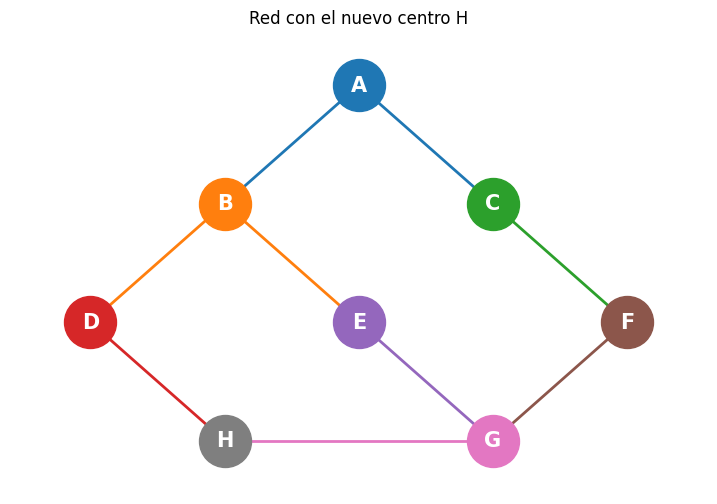

Recorrido BFS desde A: A -> B -> C -> D -> E -> F -> H -> G
  Nivel 0: A
  Nivel 1: B, C
  Nivel 2: D, E, F
  Nivel 3: H, G
Recorrido DFS desde A: A -> B -> D -> H -> G -> E -> F -> C

Si el centro buscado no tiene ninguna ruta, por ejemplo un centro I sin conexiones:
No existe una ruta hasta el centro solicitado.


In [ ]:
red = crear_grafo(nombres, carreteras)

print("PUNTO 1. Lista de adyacencia")
mostrar_grafo(red)
dibujar_red(red, "A", "Red de distribución")

print("PUNTOS 2 Y 3. Recorridos desde el centro principal")
recorrer(red, "A")

print("\nPUNTO 4. Recorridos desde el centro que elige el usuario")
recorrer(red, "B")
dibujar_red(red, "B", "Red por niveles desde B")
print("Si el usuario escribe un centro que no existe, por ejemplo Z:")
recorrer(red, "Z")

print("\nPUNTO 5. Buscar un centro con BFS")
mostrar_busqueda(red, "A", "F")

print("PUNTO 6. Agregar el centro H conectado con D y G")
agregar_centro(red, "H", ["D", "G"])
mostrar_grafo(red)
dibujar_red(red, "A", "Red con el nuevo centro H")
recorrer(red, "A")

print("\nSi el centro buscado no tiene ninguna ruta, por ejemplo un centro I sin conexiones:")
agregar_centro(red, "I", [])
mostrar_busqueda(red, "A", "I")

## 9) Tests aplicados

Se comprueba cada punto del enunciado con los datos de la guía.

In [ ]:
red = crear_grafo(nombres, carreteras)

esperado = {
    "A": ["B", "C"],
    "B": ["A", "D", "E"],
    "C": ["A", "F"],
    "D": ["B"],
    "E": ["B", "G"],
    "F": ["C", "G"],
    "G": ["E", "F"],
}
assert red == esperado

for centro, vecinos in red.items():
    for vecino in vecinos:
        assert centro in red[vecino]

orden, nivel = bfs(red, "A")
assert orden == ["A", "B", "C", "D", "E", "F", "G"]
assert niveles_por_grupo(nivel) == {0: ["A"], 1: ["B", "C"], 2: ["D", "E", "F"], 3: ["G"]}

assert dfs(red, "A") == ["A", "B", "D", "E", "G", "F", "C"]

for inicio in red:
    orden_bfs = bfs(red, inicio)[0]
    orden_dfs = dfs(red, inicio)
    assert len(orden_bfs) == len(set(orden_bfs)) == len(red)
    assert len(orden_dfs) == len(set(orden_dfs)) == len(red)

assert bfs(red, "B")[0] == ["B", "A", "D", "E", "C", "G", "F"]
assert dfs(red, "B") == ["B", "A", "C", "F", "G", "E", "D"]
assert "B" in red
assert "Z" not in red

ruta = buscar_ruta(red, "A", "F")
assert ruta == ["A", "C", "F"]
assert len(ruta) - 1 == 2
assert buscar_ruta(red, "A", "A") == ["A"]

agregar_centro(red, "H", ["D", "G"])
assert red["D"] == ["B", "H"]
assert red["G"] == ["E", "F", "H"]
assert red["H"] == ["D", "G"]

agregar_centro(red, "H", ["D"])
assert red["H"] == ["D", "G"]
assert "H" in bfs(red, "A")[0]
assert "H" in dfs(red, "A")

agregar_centro(red, "I", [])
assert buscar_ruta(red, "A", "I") is None

print("Todos los tests fueron aprobados correctamente.")

Todos los tests fueron aprobados correctamente.


### Pruebas de rendimiento

Se generan redes aleatorias conectadas de 1000 a 10000 centros, con el doble de carreteras, y se mide el tiempo de BFS, DFS y de la búsqueda de un centro.

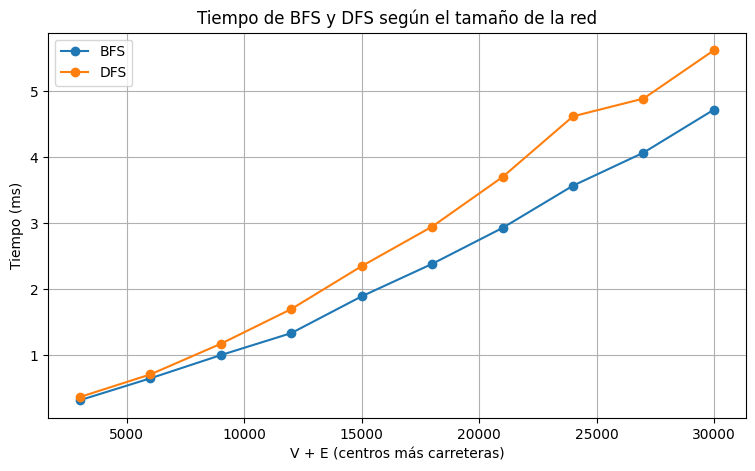

Con 10000 centros y 20000 carreteras:
BFS: 4.72 ms | DFS: 5.62 ms


In [ ]:
import random
import time

random.seed(7)


def red_aleatoria(v):
    grafo = {i: [] for i in range(v)}
    for i in range(1, v):
        conectar(grafo, i, random.randrange(i))
    aristas = v - 1
    while aristas < 2 * v:
        a, b = random.randrange(v), random.randrange(v)
        if a != b and b not in grafo[a]:
            conectar(grafo, a, b)
            aristas += 1
    return grafo, aristas


def medir(funcion, *args):
    mejor = float("inf")
    for _ in range(5):
        inicio = time.perf_counter()
        resultado = funcion(*args)
        mejor = min(mejor, time.perf_counter() - inicio)
    return mejor * 1000, resultado


tamanos = list(range(1000, 10001, 1000))
redes = []
x = []
t_bfs, t_dfs = [], []

for v in tamanos:
    grafo, e = red_aleatoria(v)
    redes.append(grafo)
    x.append(v + e)

    t, (orden, nivel) = medir(bfs, grafo, 0)
    t_bfs.append(t)
    assert len(orden) == len(set(orden)) == v

    t, orden = medir(dfs, grafo, 0)
    t_dfs.append(t)
    assert len(orden) == len(set(orden)) == v

plt.figure(figsize=(9, 5))
plt.plot(x, t_bfs, marker="o", label="BFS")
plt.plot(x, t_dfs, marker="o", label="DFS")
plt.title("Tiempo de BFS y DFS según el tamaño de la red")
plt.xlabel("V + E (centros más carreteras)")
plt.ylabel("Tiempo (ms)")
plt.grid(True)
plt.legend()
plt.show()

print(f"Con {tamanos[-1]} centros y {x[-1] - tamanos[-1]} carreteras:")
print(f"BFS: {t_bfs[-1]:.2f} ms | DFS: {t_dfs[-1]:.2f} ms")

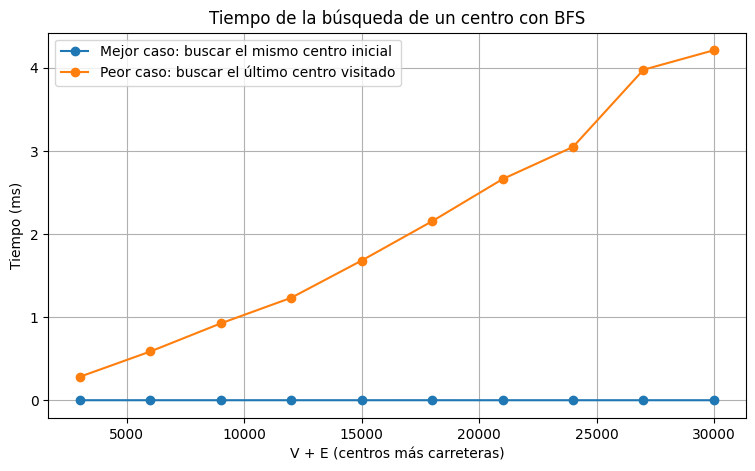

Mejor caso: 0.0006 ms | Peor caso: 4.21 ms
Todas las pruebas de rendimiento fueron aprobadas.


In [ ]:
t_mejor, t_peor = [], []

for grafo in redes:
    orden, nivel = bfs(grafo, 0)
    ultimo = orden[-1]

    t, ruta = medir(buscar_ruta, grafo, 0, 0)
    t_mejor.append(t)
    assert ruta == [0]

    t, ruta = medir(buscar_ruta, grafo, 0, ultimo)
    t_peor.append(t)
    assert ruta[0] == 0 and ruta[-1] == ultimo
    assert len(ruta) - 1 == nivel[ultimo]

plt.figure(figsize=(9, 5))
plt.plot(x, t_mejor, marker="o", label="Mejor caso: buscar el mismo centro inicial")
plt.plot(x, t_peor, marker="o", label="Peor caso: buscar el último centro visitado")
plt.title("Tiempo de la búsqueda de un centro con BFS")
plt.xlabel("V + E (centros más carreteras)")
plt.ylabel("Tiempo (ms)")
plt.grid(True)
plt.legend()
plt.show()

print(f"Mejor caso: {t_mejor[-1]:.4f} ms | Peor caso: {t_peor[-1]:.2f} ms")
print("Todas las pruebas de rendimiento fueron aprobadas.")

El tiempo de BFS y DFS crece casi en línea recta con V + E, como se esperaba en el análisis de complejidad. En la búsqueda, el mejor caso tarda prácticamente cero sin importar el tamaño de la red, mientras que el peor caso tarda lo mismo que un recorrido completo.

### Menú del programa

Esta celda va al final porque se queda esperando que el usuario escriba una opción. Para terminar se elige la opción 5.

In [ ]:
red = crear_grafo(nombres, carreteras)
menu(red)